# Modelado

En este notebook se entrenan y evalúan dos modelos de clasificación sobre el dataset CICIDS-2017 previamente procesado:

- Random Forest
- MLP (Multilayer Perceptron)

Los datos utilizados ya fueron particionados en train y test, estandarizados y balanceados mediante SMOTE sobre el conjunto de entrenamiento.

In [78]:
#Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

---
## Importacion de datos previamente procesados


In [79]:
X_train = pd.read_csv("../datos/processed/X_train.csv")
X_test = pd.read_csv("../datos/processed/X_test.csv")
Y_train = pd.read_csv("../datos/processed/Y_train.csv")
Y_test = pd.read_csv("../datos/processed/Y_test.csv")

In [80]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test:", Y_test.shape)

X_train: (11732315, 44)
X_test: (504160, 44)
y_train: (11732315, 1)
y_test: (504160, 1)


Se importaron los datos previamente procesados, y se les calculó el tamaño, para comprobar que se importaron correctamente, y no hay problemas de dimensionalidad

---
# Random Forest

A continuacion, se procedera al entrenamiento del clasificador multiclase utilizando Random Forest

Este modelo es un método de aprendizaje supervisado basado en un conjunto de árboles de decisión. El modelo construye múltiples árboles utilizando diferentes muestras y subconjuntos de variables, y combina sus predicciones para obtener una clasificación final. Esta estrategia permite reducir la dependencia de un único árbol, y a su vez, construye un modelo robusto frente a posibles relaciones no lineales entre las variables.

Para el modelado, se eligieron los siguientes hiperparámetros:
- n_estimators = 100: Se construyeron 100 árboles de decisión. El valor fue elegido como un balance entre el costo computacional y la capacidad de predicción del modelo. 
- random_state = 42: Se fija la semilla aleatoria en 42 para la reproducibilidad del proceso. Este valor no aporta ninguna ventaja estadística.
- n_jobs = 1: Se eligio usar un unico núcleo de CPU para menor costo computacional. Fue elegido empíricamente

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

modelo_rf.fit(X_train, Y_train)

RandomForestClassifier(n_jobs=1, random_state=42)

In [82]:
y_pred_rf = modelo_rf.predict(X_test)

El modelo fue entrenado con las variables X_train y Y_train, que son las variables de entrenamiento. Luego, utilizando X_test y Y_test, que son las de prueba, se realizaron las predicciones sobre estos datos que no fueron utilizados durante el entrenamiento.

Las predicciones obtenidas se utilizarán posteriormente en el notebook de Resultados para analizar el desempeño general del modelo, y compararlo con otros modelos.

---
# MLP (Multilayer Perceptron)

A continuacion, se procederá al entrenamiento del clasificador multiclase utilizando MLP (Multilayer Perceptron). 

Este modelo está compuesto por capas de neuronas interconectadas, y es capaz de aprender con mayor efectividad las relaciones no lineales entre las variables de entrada y las clases de salida.

Los hiperparámetros utilizados fueron:    
- hidden_layer_sizes=(100, 50): se definieron dos capas ocultas, con 100 y 50 neuronas respectivamente. Esta arquitectura se eligió como un balance entre que el modelo capture correctamente las relaciones mas complejas entre las variables, y mantener un costo computacional razonable al problema.
- activation='relu': se utiliza la función de activación ReLU en las capas ocultas como un estándar debido a su simplicidad computacional.
- solver='adam': se utiliza Adam como algoritmo de optimización. Es un método basado en descenso por gradiente que adapta la tasa de aprendizaje durante el entrenamiento y suele funcionar bien en redes neuronales.
- alpha=0.0001: corresponde al parámetro de regularización L2. La regularización ayuda a evitar un posible sobreajuste de los datos de entrenamiento, penalizando valores demasiado grandes de los pesos.
- batch_size=512: cada actualización de los pesos se realiza utilizando grupos de 512 observaciones. Se eligió un tamaño relativamente grande para reducir el costo computacional de procesar un conjunto de datos de gran tamaño.
- learning_rate_init=0.0001: establece la tasa de aprendizaje inicial utilizada por el optimizador. Se utiliza un valor relativamente pequeño para favorecer un proceso de aprendizaje más gradual y estable.
- max_iter=100: establece un máximo de 100 iteraciones durante el entrenamiento, cantidad considerable para capturar las relaciones.
- early_stopping=True: activa la detención anticipada del entrenamiento. El modelo utiliza una parte de los datos de entrenamiento como conjunto de validación y detiene el proceso cuando el desempeño sobre estos datos deja de mejorar.
- validation_fraction=0.1: reserva el 10% de los datos de entrenamiento para realizar la validación utilizada por early_stopping.
- n_iter_no_change=5: si el desempeño sobre el conjunto de validación no mejora durante 5 iteraciones consecutivas, el entrenamiento se detiene anticipadamente. Esto permite evitar iteraciones innecesarias y ayuda a reducir el riesgo de sobreajuste.
- random_state=42: Se fija la semilla aleatoria en 42 para la reproducibilidad del proceso. Este valor no aporta ninguna ventaja estadística.


In [83]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=512,
    learning_rate_init=0.0001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42
)

In [84]:
Y_train = np.asarray(Y_train).ravel()
Y_test = np.asarray(Y_test).ravel()

In [85]:
le = LabelEncoder()

y_train_mlp = le.fit_transform(np.asarray(Y_train).ravel())
y_test_mlp = le.transform(np.asarray(Y_test).ravel())

print("Clases:")
print(le.classes_)

print("\nForma y_train:", y_train_mlp.shape)
print("Forma y_test:", y_test_mlp.shape)

print("\nValores de y_train:")
print(np.unique(y_train_mlp))

Clases:
['BENIGN' 'Bot' 'DDoS' 'DoS' 'Other' 'PortScan' 'Web Attack']

Forma y_train: (11732315,)
Forma y_test: (504160,)

Valores de y_train:
[0 1 2 3 4 5 6]


Las variable objetivo 'Label' fue codificada numéricamente debido a el modelo mlp requería una representación numérica.

In [86]:
mlp.fit(X_train, y_train_mlp)

MLPClassifier(batch_size=512, early_stopping=True, hidden_layer_sizes=(100, 50),
              learning_rate_init=0.0001, max_iter=100, n_iter_no_change=5,
              random_state=42)

In [87]:
print("Iteraciones realizadas:", mlp.n_iter_)
print("Pérdida final:", mlp.loss_)

Iteraciones realizadas: 31
Pérdida final: 0.02473439184589429


In [88]:
y_pred_mlp = mlp.predict(X_test)

El modelo fue entrenado con las variables X_train y Y_train, que son las variables de entrenamiento. Luego, utilizando X_test y Y_test, que son las de prueba, se realizaron las predicciones sobre estos datos que no fueron utilizados durante el entrenamiento.

Las predicciones obtenidas se utilizarán posteriormente en el notebook de Resultados para analizar el desempeño general del modelo, y compararlo con otros modelos.

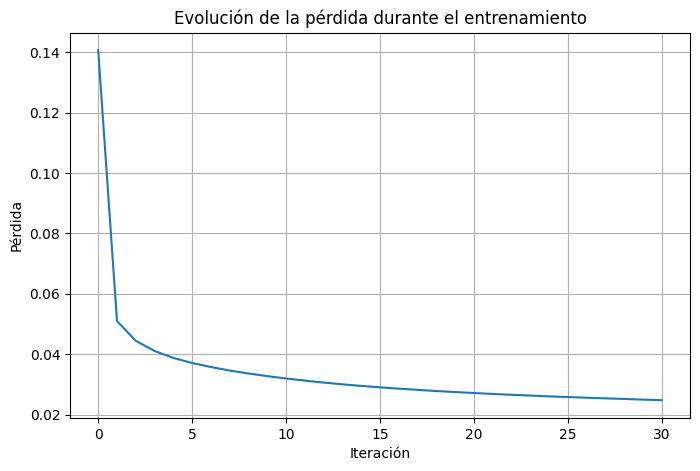

In [89]:
plt.figure(figsize=(8, 5))

plt.plot(mlp.loss_curve_)

plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.grid(True)

plt.show()

Para comprobar gráficamente el funcionamiento del modelado, se escogió usar un gráfico que muestra la evolución de la función de pérdida en cada iteración. Se observa que a medida que pasan las iteraciones la función de pérdida disminuye, por lo que se podría concluir que el modelo funciona.

Otra cosa que se observa en el gráfico es que, a pesar de que la cantidad de iteraciones definida como hiperparánetro es 100, el early_stopping=True actuó antes de llegar a las 100, debido a que la función de pérdida no presentaba mejoras significativas en las iteraciones.

In [90]:
y_pred_mlp = le.inverse_transform(y_pred_mlp)

Una vez terminado el modelado, realizamos la codificación inversa, para preservar las etiquetas originales en el análisis de resultados.

---
# Exportación de resultados

In [96]:
y_proba_mlp = mlp.predict_proba(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)

In [97]:
np.save("../datos/processed/y_proba_mlp.npy", y_proba_mlp)
np.save("../datos/processed/y_proba_rf.npy", y_proba_rf)

Guardado de datos necesario para graficar curvas ROC y AUC

In [91]:
resultados = pd.DataFrame({

    "y_test": Y_test,

    "y_pred_mlp": y_pred_mlp,

    "y_pred_rf": y_pred_rf

})

resultados.to_csv("../datos/processed/predicciones.csv", index=False)